正在执行两表合并...

开始生成图表...


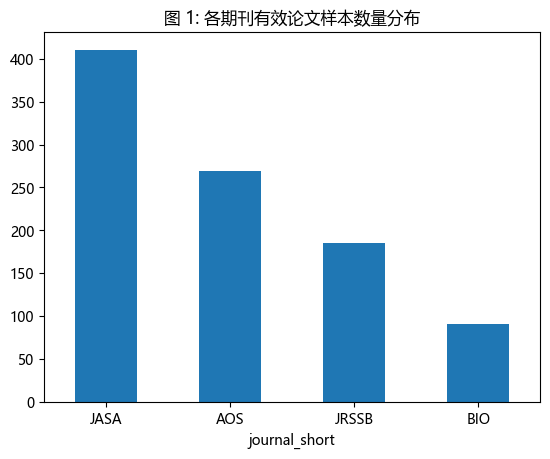

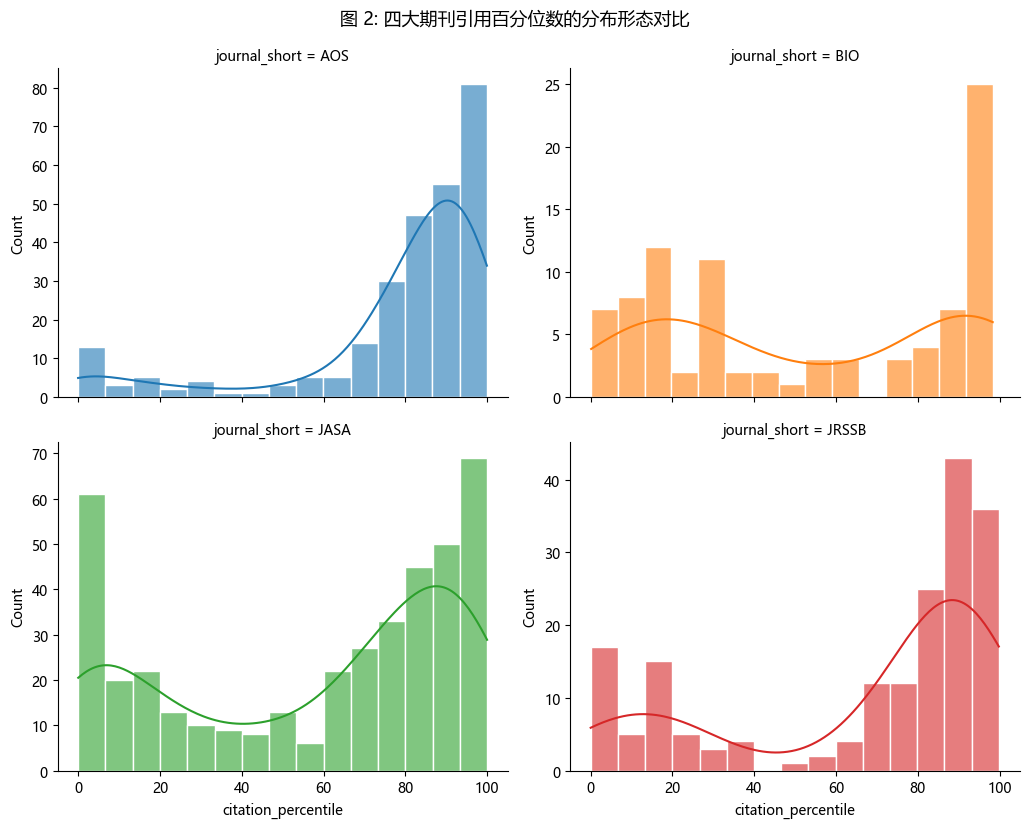

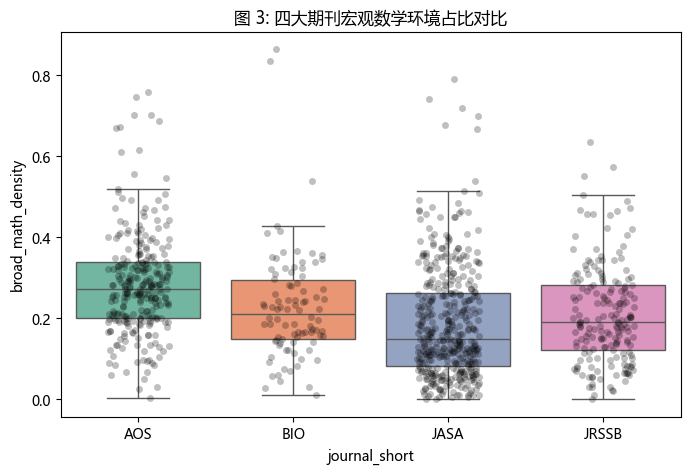

-> 正在生成: 图 4-1: 宏观数学强度回归分析 (原始)


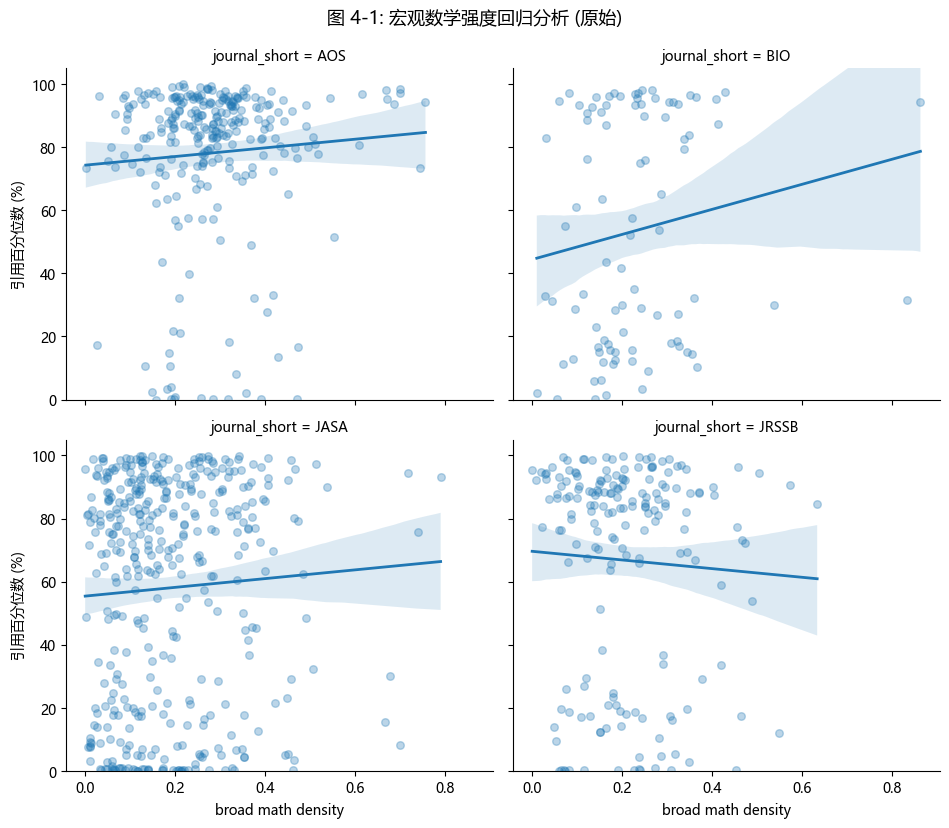

-> 正在生成: 图 4-2: 严谨数学强度回归分析 (原始)


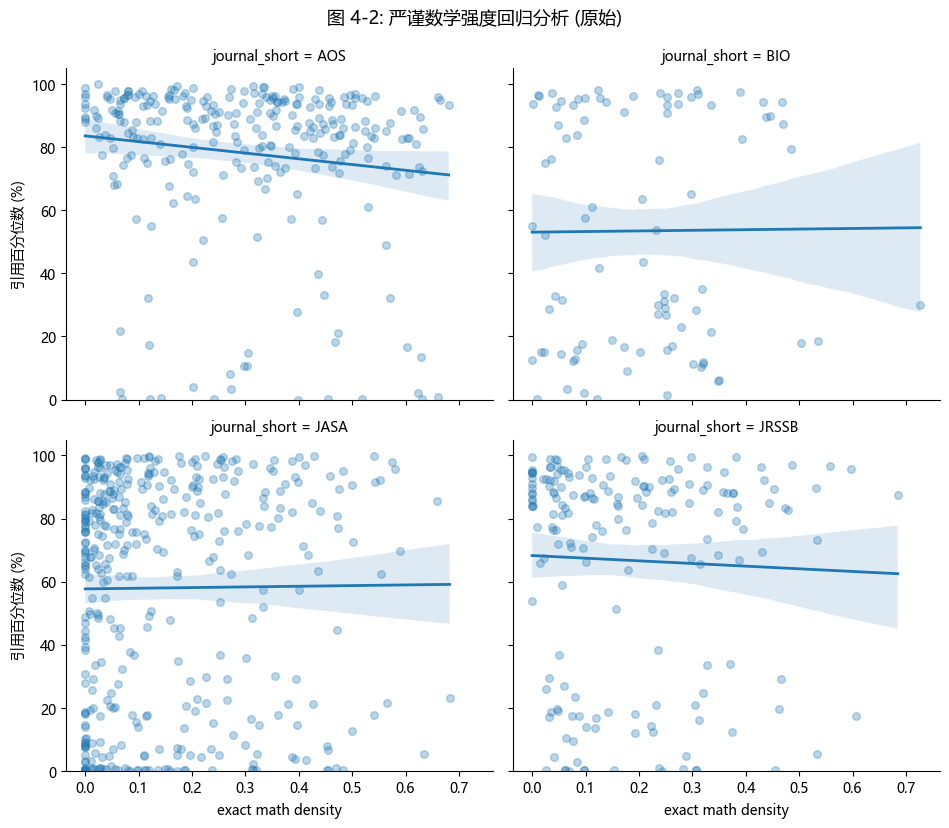

-> 正在生成: 图 4-3: 宏观数学强度回归分析 (按50%分组)


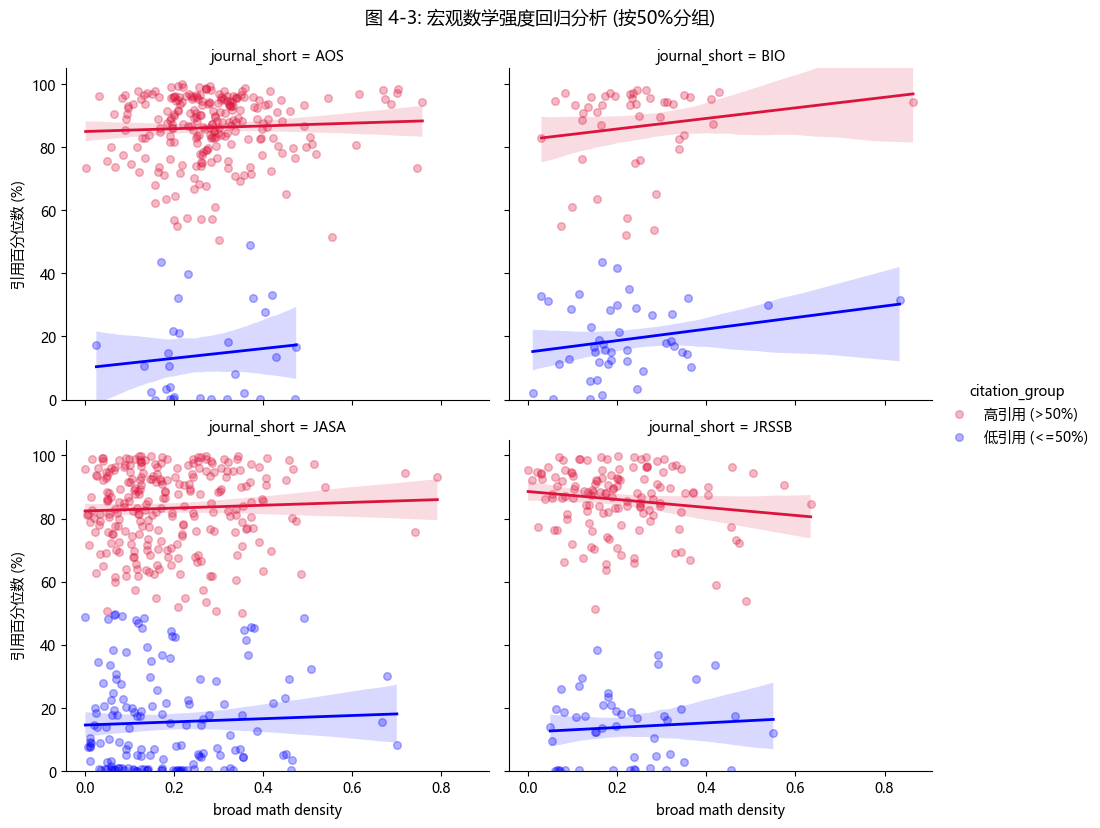

-> 正在生成: 图 4-4: 严谨数学强度回归分析 (按50%分组)


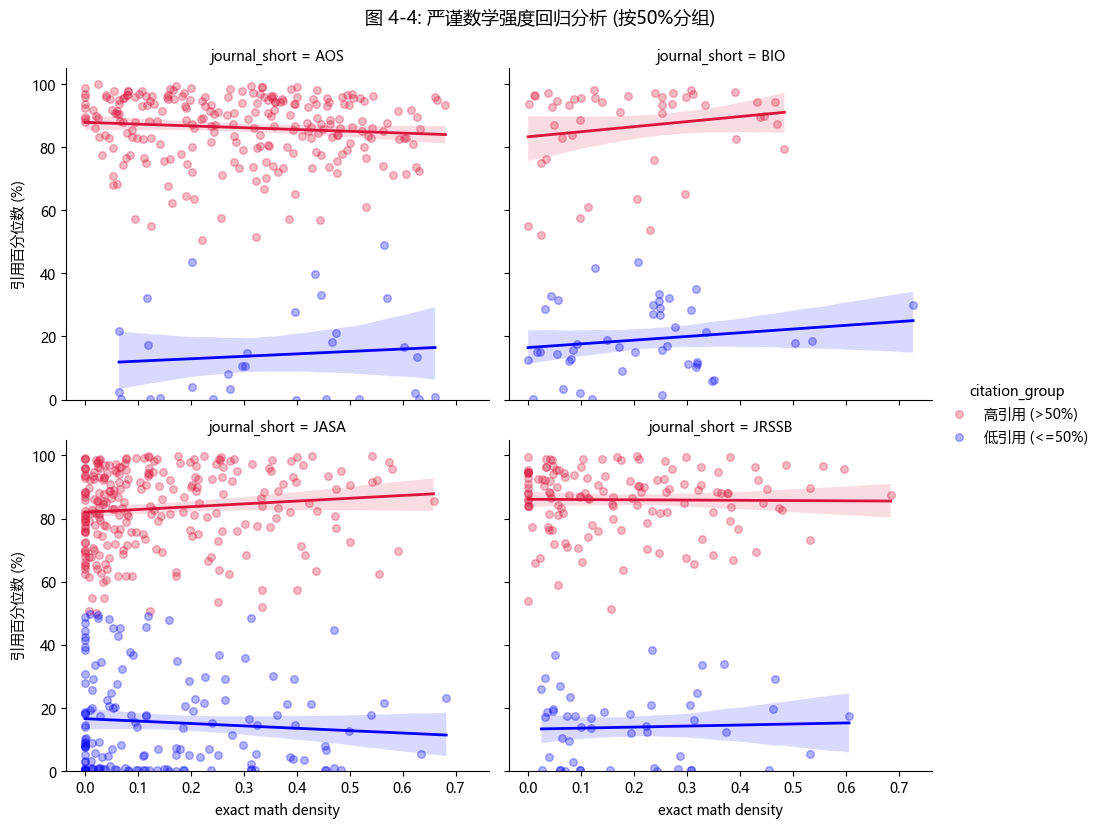

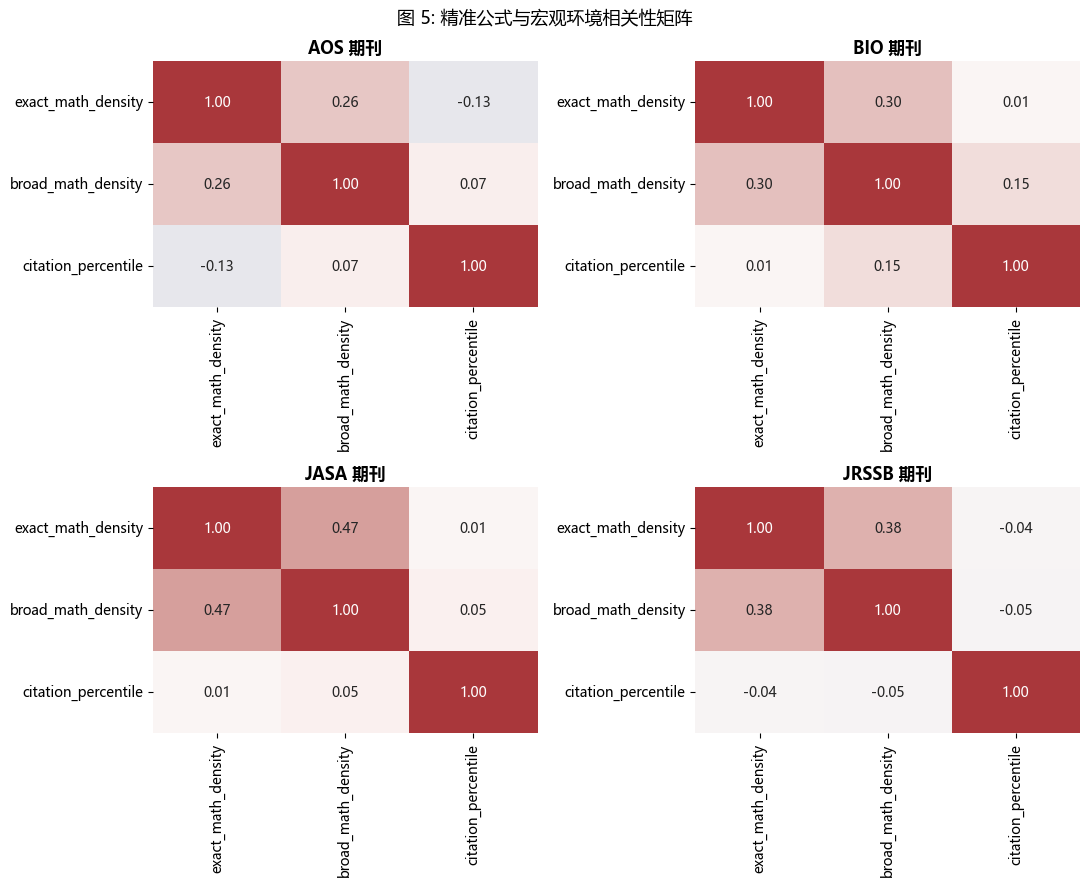

-> 正在绘制图 6...


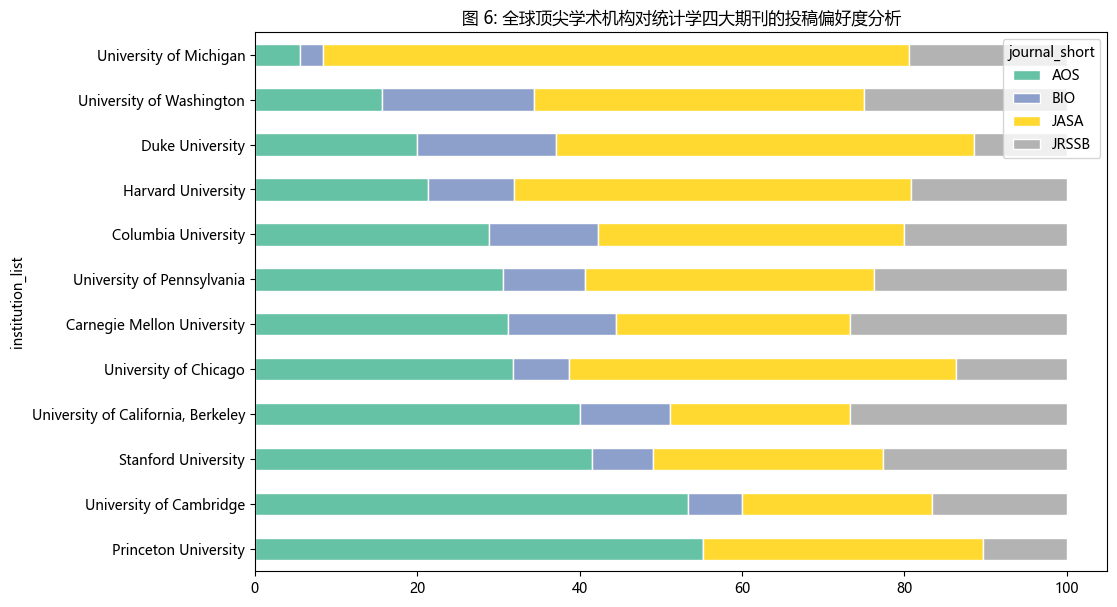

-> 正在绘制图 7...


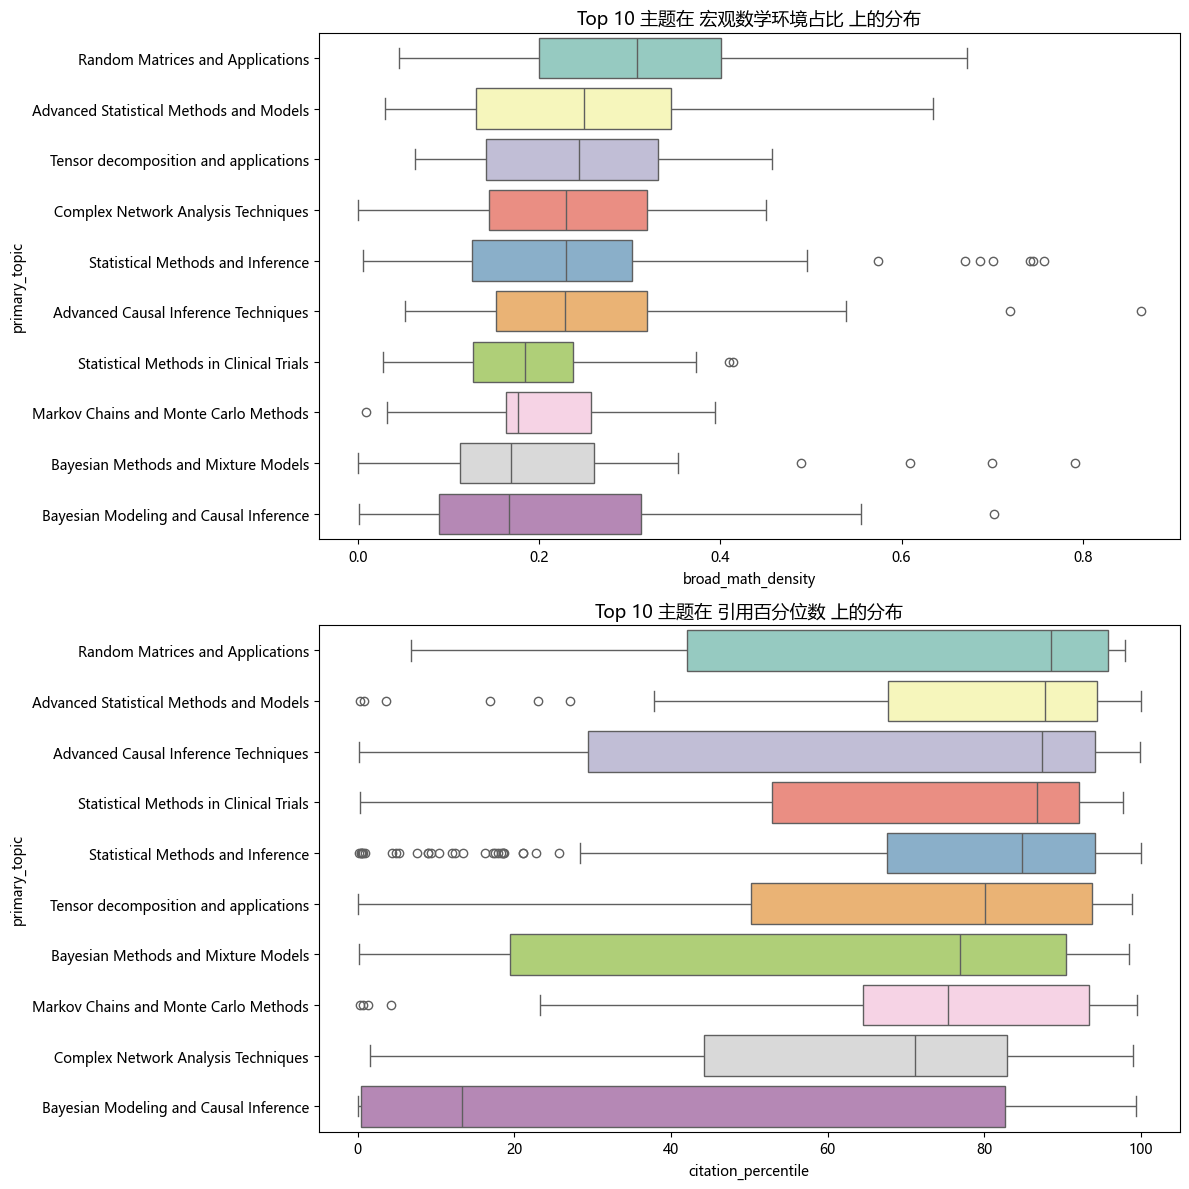


执行统计学 ANOVA 检验...
-> [期刊间数学密度差异] p-value: 4.8960E-19
-> [主题间数学密度差异] p-value: 7.7284E-02
-> [主题间引用差异] p-value: 9.6403E-04
所有图表与 'final_outcome.csv' 已生成。


In [ ]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
warnings.filterwarnings('ignore')

# --- 2. 数据加载与预处理 ---
meta = pd.read_csv(r'C:\Users\lihong\.conda\stat4_2023_2026_metadata.csv')
latex = pd.read_csv(r'C:\Users\lihong\.conda\all_latex_features_results.csv')

print("正在执行两表合并...")
df = pd.merge(meta, latex, on='paper_id', how='inner')

# 预计算 50% 分位分组标签 (用于后续回归分析)
df['citation_group'] = np.where(df['citation_percentile'] >= 50, '高引用 (>50%)', '低引用 (<=50%)')

# --- 3. 辅助函数：简化绘图逻辑 ---
def plot_regression(data, x, title, filename, hue=None):
    print(f"-> 正在生成: {title}")
    g = sns.lmplot(
        data=data, x=x, y='citation_percentile', col='journal_short', 
        col_wrap=2, height=4, aspect=1.2, hue=hue,
        palette={'高引用 (>50%)': 'crimson', '低引用 (<=50%)': 'blue'} if hue else None,
        scatter_kws={'alpha': 0.3, 's': 30}, line_kws={'lw': 2}
    )
    g.set(ylim=(0, 105), xlabel=x.replace('_', ' '), ylabel='引用百分位数 (%)')
    g.figure.suptitle(title, fontsize=13, y=1.03)
    plt.savefig(f'{filename}', dpi=300, bbox_inches='tight')
    plt.show()

# --- 4. 可视化生成 ---
print("\n开始生成图表...")

# 图 1: 各期刊样本数
df['journal_short'].value_counts().plot(kind='bar', rot=0, title='图 1: 各期刊有效论文样本数量分布')
plt.savefig(f'fig1_journal_count.png', dpi=300)
plt.show()

# 图 2: 引用分布
g2 = sns.FacetGrid(data=df, col="journal_short", col_wrap=2, height=4, aspect=1.3, sharey=False, hue="journal_short")
g2.map_dataframe(sns.histplot, x="citation_percentile", bins=15, kde=True, edgecolor="white", alpha=0.6)
g2.figure.suptitle('图 2: 四大期刊引用百分位数的分布形态对比', fontsize=13, y=1.03)
plt.savefig(f'fig2_percentile_dist.png', dpi=300, bbox_inches='tight')
plt.show()

# 图 3: 箱线图
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='journal_short', y='broad_math_density', palette='Set2', showfliers=False)
sns.stripplot(data=df, x='journal_short', y='broad_math_density', color='black', alpha=0.25, jitter=0.2)
plt.title('图 3: 四大期刊宏观数学环境占比对比')
plt.savefig(f'fig3.png', dpi=300)
plt.show()

# 图 4 系列 (共 4 张回归图)
plot_regression(df, 'broad_math_density', '图 4-1: 宏观数学强度回归分析 (原始)', 'fig4_1_orig.png')
plot_regression(df, 'exact_math_density', '图 4-2: 严谨数学强度回归分析 (原始)', 'fig4_2_orig.png')
plot_regression(df, 'broad_math_density', '图 4-3: 宏观数学强度回归分析 (按50%分组)', 'fig4_3_split.png', hue='citation_group')
plot_regression(df, 'exact_math_density', '图 4-4: 严谨数学强度回归分析 (按50%分组)', 'fig4_4_split.png', hue='citation_group')

# 图 5: 相关性热力图
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
cols = ['exact_math_density', 'broad_math_density', 'citation_percentile']
for ax, journal in zip(axes.flatten(), df['journal_short'].unique()):
    corr = df[df['journal_short'] == journal][cols].corr()
    sns.heatmap(corr, ax=ax, annot=True, cmap='vlag', center=0, fmt=".2f", cbar=False)
    ax.set_title(f'{journal} 期刊', fontsize=12, fontweight='bold')
plt.suptitle('图 5: 精准公式与宏观环境相关性矩阵', fontsize=13, y=0.98)
plt.tight_layout()
plt.savefig(f'fig5.png', dpi=300)
plt.show()

# 图 6: 机构偏好
print("-> 正在绘制图 6...")
df_inst = df.copy()
df_inst['institution_list'] = df_inst['institution_names'].fillna('').str.split('|')
df_exploded = df_inst.explode('institution_list').reset_index(drop=True)
df_exploded['institution_list'] = df_exploded['institution_list'].str.strip()
df_exploded = df_exploded[df_exploded['institution_list'] != '']

top_inst = df_exploded['institution_list'].value_counts().head(12).index
df_top = df_exploded[df_exploded['institution_list'].isin(top_inst)]
inst_pct = pd.crosstab(df_top['institution_list'], df_top['journal_short'], normalize='index') * 100
inst_pct.sort_values(by=inst_pct.columns[0], ascending=False, inplace=True)

inst_pct.plot(kind='barh', stacked=True, figsize=(11, 7), cmap='Set2', edgecolor='white')
plt.title('图 6: 全球顶尖学术机构对统计学四大期刊的投稿偏好度分析')
plt.savefig(f'fig6_inst_preference.png', dpi=300)
plt.show()

# 图 7: 主题对比
print("-> 正在绘制图 7...")
top_10 = df['primary_topic'].value_counts().head(10).index
df_top = df[df['primary_topic'].isin(top_10)]
fig, axes = plt.subplots(2, 1, figsize=(12, 12))
metrics = [('broad_math_density', '宏观数学环境占比'), ('citation_percentile', '引用百分位数')]
for ax, (col, label) in zip(axes, metrics):
    order = df_top.groupby('primary_topic')[col].median().sort_values(ascending=False).index
    sns.boxplot(data=df_top, x=col, y='primary_topic', order=order, ax=ax, palette='Set3')
    ax.set_title(f'Top 10 主题在 {label} 上的分布', fontsize=13)
plt.tight_layout()
plt.savefig(f'fig7_top10_topic_comparison.png', dpi=300)
plt.show()

# --- 5. 统计学检验 (ANOVA) ---
print("\n执行统计学 ANOVA 检验...")
def run_anova(groups, name):
    valid = [g.dropna() for g in groups if len(g.dropna()) >= 5]
    stat, p_val = f_oneway(*valid) if len(valid) > 1 else (np.nan, np.nan)
    print(f"-> [{name}] p-value: {p_val:.4E}")
    return p_val

run_anova([df[df['journal_short'] == j]['broad_math_density'] for j in df['journal_short'].unique()], "期刊间数学密度差异")
run_anova([df[df['primary_topic'] == t]['broad_math_density'] for t in top_10], "主题间数学密度差异")
run_anova([df[df['primary_topic'] == t]['citation_percentile'] for t in top_10], "主题间引用差异")

# --- 6. 数据导出 ---
core_columns = [
    'paper_id', 'title', 'journal_short', 'publication_year', 
    'institution_names', 'primary_topic', 
    'cited_by_count', 'citation_percentile', 
    'exact_math_density', 'broad_math_density'
]
df[core_columns].to_csv('final_outcome.csv', index=False, encoding='utf-8-sig')
print("所有图表与 'final_outcome.csv' 已生成。")